In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from task_decomposition.analysis.comparisons import (get_subtask_similarity,
                                                    #  get_IOU,
                                                    #  get_semantic_distance,
                                                     extract_subtask_from_groundtruth_file,
                                                     extract_subtask_from_LLM_output_file,
                                                     extract_subtask_from_annotation_file,
                                                     extract_user_from_annotation_file,
                                                    #  extract_timespent_from_annotation_file
                                                    )
# from task_decomposition.utils.random_subtask_decomposition import get_random_subtask_decomposition
from task_decomposition.paths import (ROBOT_TRAJ_GROUNDTRUTH_DATA_PATH, 
                                      LLM_OUTPUT_PATH,
                                    # ANNOTATION_PATH,
                                      # SAVE_PLOTS_PATH,
                                      # BASELINES_DATA
                                      )
from task_decomposition.constants import (START_STEP_IDX, 
                                          # END_STEP_IDX, 
                                          # DESCRIPTION_IDX, 
                                          ENVIRONMENT_NAMES)

In [6]:
def _get_filepaths(env_name: str, 
                   llm_model: str, 
                   input_mode: str,  
                   kind:str, 
                   in_context: bool) -> list:
    """
    Get the list of groundtruth or LLM human_and_baseline filepaths for a given environment
    """
    if kind == "groundtruth":
        files_path = ROBOT_TRAJ_GROUNDTRUTH_DATA_PATH(env_name)
    elif kind == "llm_output":
        files_path = LLM_OUTPUT_PATH(llm_model=llm_model, 
                                     input_mode=input_mode, 
                                     env_name=env_name,
                                     in_context=in_context)
    else:
        raise ValueError(f"Invalid kind {kind}. Must be either 'groundtruth' or 'llm_outputs'.")
    files = os.listdir(files_path)
    files.remove(".gitkeep") if ".gitkeep" in files else None
    files.remove(".DS_Store") if ".DS_Store" in files else None
    files = [os.path.join(files_path, file) for file in files]
    files = sorted(files)
    return files

### Plot Annotations

In [41]:
# Find out who is the most similar to the groundtruth
# There is one human annotation file per ground truth file

# Loop through all ground truth files and find the most similar human annotation file
human_and_baseline = {}
human_and_gpt = {}
GPT_MODEL = "gpt-4-vision-preview"
for env_name in ENVIRONMENT_NAMES:
    print(f"Environment: {env_name}")
    gt_files = _get_filepaths(
        env_name=env_name,
        llm_model=None,
        input_mode=None,
        in_context=None,
        kind="groundtruth",
    )
    gpt_files = _get_filepaths(
        env_name=env_name,
        llm_model=GPT_MODEL,
        input_mode="textualvideo",
        in_context=True,
        kind="llm_output",
    )
    # print(f"Env: {env_name}")
    n_runs = len(gt_files)
    groundtruth_annotation = {
        "runid": np.full(n_runs, np.nan),
        "user": np.full(n_runs, np.nan),
        "semantic": np.full(n_runs, np.nan),
        "temporal": np.full(n_runs, np.nan),
    }
    human_and_baseline[env_name] = {"temporal": np.full(n_runs, np.nan), 
                        "semantic": np.full(n_runs, np.nan),
                        "user": np.full(n_runs, None)}
    human_and_gpt[env_name] = {"temporal": np.full(n_runs, np.nan), 
                                "semantic": np.full(n_runs, np.nan),
                                "user": np.full(n_runs, None)}

    for idx, (gt_file, gpt_file) in enumerate(zip(gt_files, gpt_files)):
        gt_subtask_decomposition = extract_subtask_from_groundtruth_file(filepath=gt_file)
        gpt_subtask_decomposition = extract_subtask_from_LLM_output_file(filepath=gpt_file, 
                                                                         llm_model=GPT_MODEL)

        runid = gt_file.split("/")[-1].split("_gt")[0]
        annotation_subtask_decomposition = extract_subtask_from_annotation_file(
            runid=runid
        )
        annotation_user = extract_user_from_annotation_file(runid=runid)

        # compare the subtasks
        try:
            human_gt_similarity = get_subtask_similarity(
                gt_subtask_decomposition, annotation_subtask_decomposition
            )
            human_gpt_similarity = get_subtask_similarity(
                gpt_subtask_decomposition, annotation_subtask_decomposition
            )

        except Exception as e:
            print(f" Error with {runid}: {e}")
            continue
        human_and_baseline[env_name]["temporal"][idx] = human_gt_similarity["temporal"]
        human_and_baseline[env_name]["semantic"][idx] = human_gt_similarity["semantic"]
        human_and_baseline[env_name]["user"][idx] = annotation_user

        human_and_gpt[env_name]["temporal"][idx] = human_gpt_similarity["temporal"]
        human_and_gpt[env_name]["semantic"][idx] = human_gpt_similarity["semantic"]
        human_and_gpt[env_name]["user"][idx] = annotation_user
        # human_and_baseline[env_name]["total"][idx] = similarity["total"]
        # if verbose:
        #     print(f"{gt_runid} and {llm_runid}")
        #     print(f" Temporal: {similarity['temporal']:.2f} | Semantic: {similarity['semantic']:.2f}")

    # Clean the human_and_baseline in case nans are present
    # human_and_baseline[env_name]["temporal"] = human_and_baseline[env_name]["temporal"][~np.isnan(human_and_baseline[env_name]["temporal"])]
    # human_and_baseline[env_name]["semantic"] = human_and_baseline[env_name]["semantic"][~np.isnan(human_and_baseline[env_name]["semantic"])]
    # human_and_baseline[env_name]["total"] = human_and_baseline[env_name]["total"][~np.isnan(human_and_baseline[env_name]["total"])]

    # if SAVE_OUTPUT:
    #     np.savez(f"{ANNOTATION_PATH}/{env_name}_results.npz", **human_and_baseline)

    # print(f"  Number of runs: {n_runs}, Number of valid runs: {len(human_and_baseline[env_name]['temporal'])}")
    # print(
    #     f"  Temporal: {np.mean(human_and_baseline[env_name]['temporal']):.2f}+/-{np.std(human_and_baseline[env_name]['temporal']):.2f} |  Semantic: {np.mean(human_and_baseline[env_name]['semantic']):.2f}+/-{np.std(human_and_baseline[env_name]['semantic']):.2f}"
    # )

Environment: Door
Environment: Lift
Environment: PickPlace
Environment: Stack
 Error with Stack_20240220-130918_23: Invalid subtask: start index after end index


In [112]:
# Drop the following data points from the analysis
USERS_TO_DROP = [
    "cevahir",
    "ligma",
    "snarf-snarf",
    "jsalfity",
    "Sai Shankar",
    "phl"
]
UGRADS = ["Sanat", "ben", "Andon", "mathewh", "jlyle"]
GRADS = [
    "talal",
    "selma",
    "Caleb",
    "agnes",
    "kevin_torres",
    "cpetlowany",
    "fregal",
    "swanbeck",
]

# Need each user to have their unique color and marker
def plot_environment_data(env_name, data, ax):
    temporal = np.array(data[env_name]["temporal"])
    semantic = np.array(data[env_name]["semantic"])
    user = np.array(data[env_name]["user"])

    # Filter out users to drop
    mask = ~np.isin(user, USERS_TO_DROP)
    temporal = temporal[mask]
    semantic = semantic[mask]
    user = user[mask]

    # Set up colors and markers
    markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h']
    colors = sns.color_palette("husl", len(set(user)))  # Unique colors for users

    # Plot each user with distinction between UGRADS and GRADS
    plotted_users = set()
    for idx, u in enumerate(set(user)):
        mask = user == u
        ax.scatter(
            temporal[mask],
            semantic[mask],
            edgecolor=colors[idx],
            facecolor="none" if u in UGRADS else colors[idx],
            marker=markers[idx % len(markers)],
            label=u if u not in plotted_users else "",
            s=100
        )
        plotted_users.add(u)

    # Add labels and legend
    ax.set_xlabel("Temporal similarity")
    ax.set_ylabel("Semantic similarity")
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.set_title(env_name, fontsize=16)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Users")
    ax.grid(True)

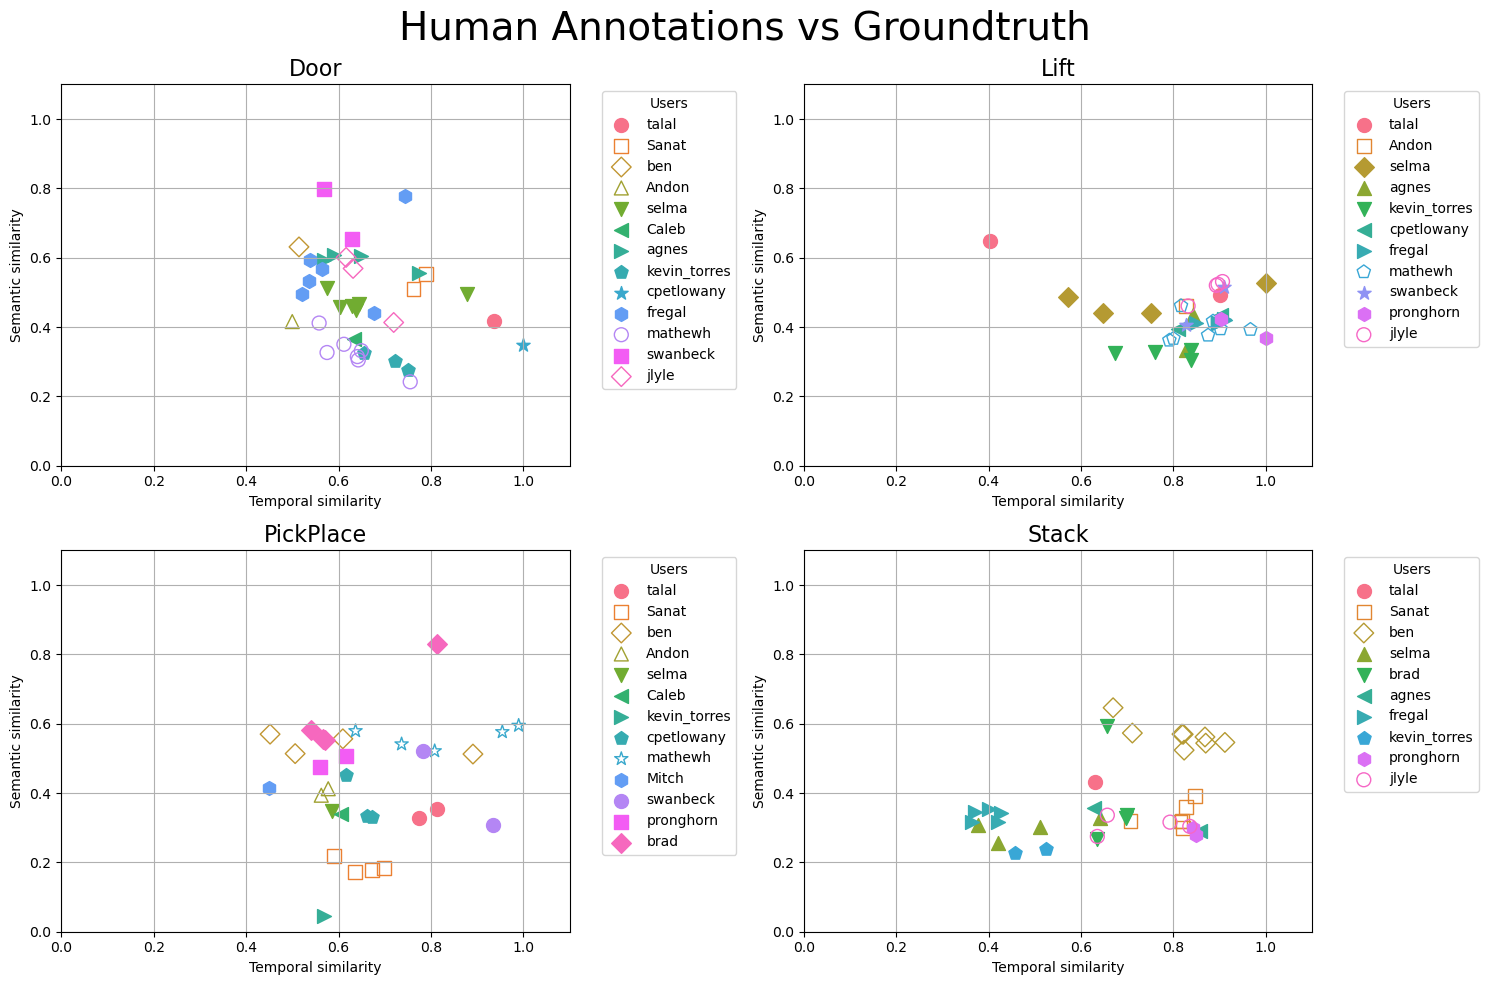

In [113]:
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten()

for i, env_name in enumerate(ENVIRONMENT_NAMES):
    plot_environment_data(env_name=env_name, data=human_and_baseline, ax=axs[i])

plt.suptitle("Human Annotations vs Groundtruth", fontsize=28)
plt.tight_layout()
plt.show()

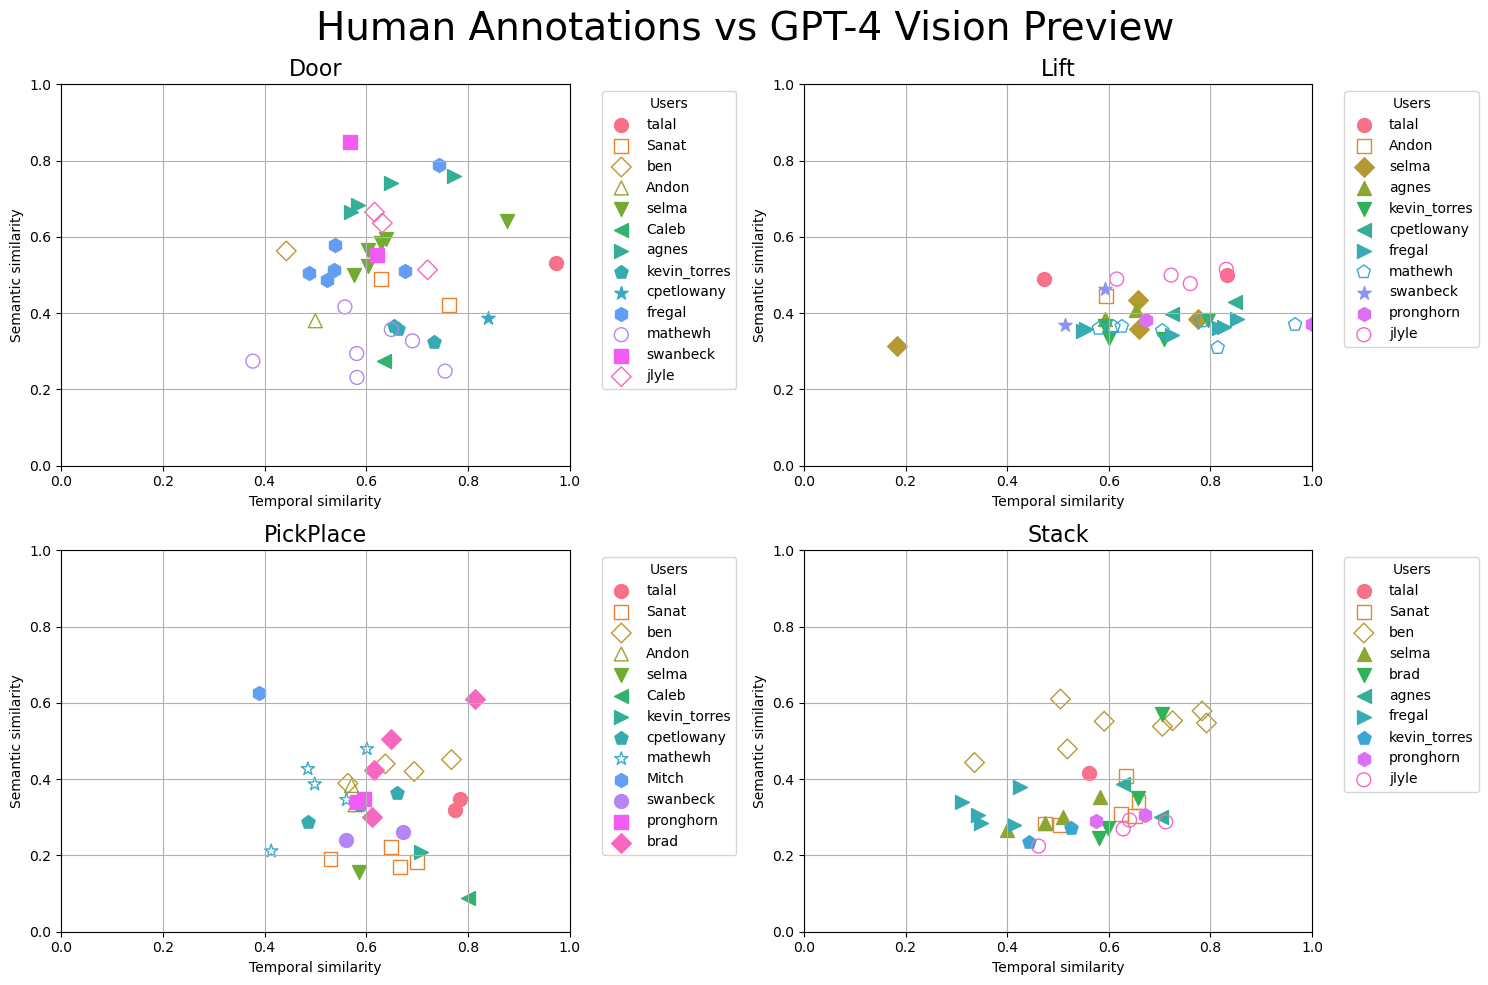

In [111]:
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten()

for i, env_name in enumerate(ENVIRONMENT_NAMES):
    plot_environment_data(env_name=env_name, data=human_and_gpt, ax=axs[i])

plt.suptitle("Human Annotations vs GPT-4 Vision Preview", fontsize=28)
plt.tight_layout()
plt.show()